# Bayesian belief simulation in a 3-state, 3-signal model

This notebook simulates Bayesian updating for three hidden states:

- `0 = Sick1`
- `1 = Sick2`
- `2 = Healthy`

and three observable signals:

- `0`
- `1`
- `2`

The likelihood matrix is interpreted as

\[
L_{s,x} = p(x \mid s),
\]

so **each row must sum to 1**.

The notebook:
1. builds the likelihood matrix,
2. simulates signals from a true hidden state,
3. updates beliefs in both probability space and log space,
4. computes centered log-likelihood increments,
5. plots the posterior path on the 2D simplex.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Likelihood matrix

We parameterize the likelihood matrix as

\[
L=
\begin{pmatrix}
\alpha & \beta & 1-\alpha-\beta\\
\beta & \alpha & 1-\alpha-\beta\\
z & z & 1-2z
\end{pmatrix},
\]

where:

- `alpha` and `beta` distinguish the two sickness states,
- `z` is small for the healthy state.


In [3]:
def make_likelihood(alpha=0.6, beta=0.3, z=0.15):
    """
    Returns a 3x3 likelihood matrix L with entries L[s, x] = p(x | s).

    States:
        s = 0 -> Sick1
        s = 1 -> Sick2
        s = 2 -> Healthy

    Signals:
        x = 0, 1, 2
    """
    L = np.array([
        [alpha, beta, 1 - alpha - beta],
        [beta, alpha, 1 - alpha - beta],
        [z,    z,     1 - 2*z]
    ], dtype=float)

    if np.any(L < 0):
        raise ValueError("Likelihood matrix has negative entries.")
    if not np.allclose(L.sum(axis=1), 1.0):
        raise ValueError("Each row of p(x|s) must sum to 1.")

    return L

## Bayesian updating

In [4]:
def bayes_update(prior, signal, L):
    """
    prior: shape (3,), prior over states
    signal: observed x in {0,1,2}
    L: likelihood matrix with L[s,x] = p(x|s)

    Returns posterior p(s | x).
    """
    likelihood_col = L[:, signal]
    unnorm = prior * likelihood_col
    posterior = unnorm / unnorm.sum()
    return posterior


def update_log_beliefs(log_prior, signal, L):
    """
    Log-space update:
        log p_{t+1}(s) = log p_t(s) + log p(x_t | s) - log Z_t

    Returns normalized log posterior.
    """
    log_likelihood = np.log(L[:, signal])
    log_unnorm = log_prior + log_likelihood

    m = np.max(log_unnorm)
    log_Z = m + np.log(np.sum(np.exp(log_unnorm - m)))

    log_posterior = log_unnorm - log_Z
    return log_posterior

## Centered log-likelihood increments

The raw log-likelihood vector is

\[
\delta_x(s)=\log p(x\mid s),
\]

but these entries are always non-positive. To get a vector that can be positive, zero, or negative across coordinates, we center it:

\[
\tilde{\delta}_x(s)=\log p(x\mid s)-c_x.
\]

With geometric centering, one state is:
- positive if above the geometric mean of the column,
- zero if equal to it,
- negative if below it.


In [5]:
def centered_log_increment(signal, L, center="geometric"):
    """
    Returns a centered log-likelihood vector for a given observed signal.

    center="geometric" subtracts log geometric mean of the column.
    center="arithmetic" subtracts log arithmetic mean of the column.
    """
    col = L[:, signal]
    log_col = np.log(col)

    if center == "geometric":
        c = np.mean(log_col)
    elif center == "arithmetic":
        c = np.log(np.mean(col))
    else:
        raise ValueError("center must be 'geometric' or 'arithmetic'")

    return log_col - c

## Simulation

In [6]:
def simulate(true_state=0, T=25, L=None, prior=None, seed=0):
    """
    Simulate T signals from a true hidden state, and update beliefs over time.
    """
    rng = np.random.default_rng(seed)

    if L is None:
        L = make_likelihood()

    if prior is None:
        prior = np.array([1/3, 1/3, 1/3], dtype=float)

    posterior_history = [prior.copy()]
    log_history = [np.log(prior)]
    signals = []

    current_posterior = prior.copy()
    current_log = np.log(prior)

    for _ in range(T):
        x = rng.choice(3, p=L[true_state])
        signals.append(x)

        current_posterior = bayes_update(current_posterior, x, L)
        posterior_history.append(current_posterior.copy())

        current_log = update_log_beliefs(current_log, x, L)
        log_history.append(current_log.copy())

    return {
        "signals": np.array(signals),
        "posterior_history": np.array(posterior_history),
        "log_history": np.array(log_history),
        "L": L
    }

## Simplex plotting helpers

Because the posterior \((p_0,p_1,p_2)\) lies on the simplex \(p_0+p_1+p_2=1\), we can plot it inside an equilateral triangle.


In [7]:
def simplex_to_cartesian(p):
    """
    Map p = (p0, p1, p2), p0+p1+p2=1 to 2D coordinates in an equilateral triangle.
    """
    v0 = np.array([0.0, 0.0])                  # corner for state 0
    v1 = np.array([1.0, 0.0])                  # corner for state 1
    v2 = np.array([0.5, np.sqrt(3)/2])         # corner for state 2
    return p[0]*v0 + p[1]*v1 + p[2]*v2


def plot_simplex_path(posterior_history, true_state=None):
    """
    Plot posterior trajectory in the 2D simplex.
    """
    triangle = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, np.sqrt(3)/2],
        [0.0, 0.0]
    ])

    coords = np.array([simplex_to_cartesian(p) for p in posterior_history])

    plt.figure(figsize=(7, 7))
    plt.plot(triangle[:, 0], triangle[:, 1], 'k-', lw=1.5)
    plt.plot(coords[:, 0], coords[:, 1], marker='o', alpha=0.8)

    plt.text(-0.05, -0.05, "Sick1")
    plt.text(1.02, -0.05, "Sick2")
    plt.text(0.44, np.sqrt(3)/2 + 0.04, "Healthy")

    plt.scatter(coords[0, 0], coords[0, 1], s=100, marker='s', label='Start')
    plt.scatter(coords[-1, 0], coords[-1, 1], s=120, marker='*', label='End')

    title = "Posterior path on simplex"
    if true_state is not None:
        title += f" (true state = {true_state})"
    plt.title(title)

    plt.axis('equal')
    plt.axis('off')
    plt.legend()
    plt.show()

## Example run

In [12]:
# Example likelihood matrix
L = np.array([
    [0.6,  0.3,  0.1],
    [0.3,  0.6,  0.1],
    [0.15, 0.15, 0.7]
], dtype=float)

print("Likelihood matrix L = p(x|s):")
print(L)
print("\nRow sums:")
print(L.sum(axis=1))

prior = np.array([1/3, 1/3, 1/3], dtype=float)

# Example centered increment for observed signal x = 0
inc = centered_log_increment(signal=0, L=L, center="geometric")
print("\nCentered log-likelihood increment for signal x = 0:")
print(inc)
print("Signs:", np.sign(inc))

# Simulate a trajectory when the true state is Sick1
result = simulate(true_state=0, T=100, L=L, prior=prior, seed=42)

print("\nObserved signals:")
print(result["signals"])

print("\nFinal posterior:")
print(result["posterior_history"][-1])

print("\nFinal log posterior:")
print(result["log_history"][-1])

Likelihood matrix L = p(x|s):
[[0.6  0.3  0.1 ]
 [0.3  0.6  0.1 ]
 [0.15 0.15 0.7 ]]

Row sums:
[1. 1. 1.]

Centered log-likelihood increment for signal x = 0:
[ 0.69314718  0.         -0.69314718]
Signs: [ 1.  0. -1.]

Observed signals:
[1 0 1 1 0 2 1 1 0 0 0 2 1 1 0 0 0 0 1 1 1 0 2 1 1 0 0 0 0 1 1 2 0 0 0 0 0
 0 0 1 0 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0
 0 0 0 1 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 2]

Final posterior:
[9.99999970e-01 2.98023215e-08 3.67994103e-43]

Final log posterior:
[-2.98023219e-08 -1.73286795e+01 -9.77082623e+01]


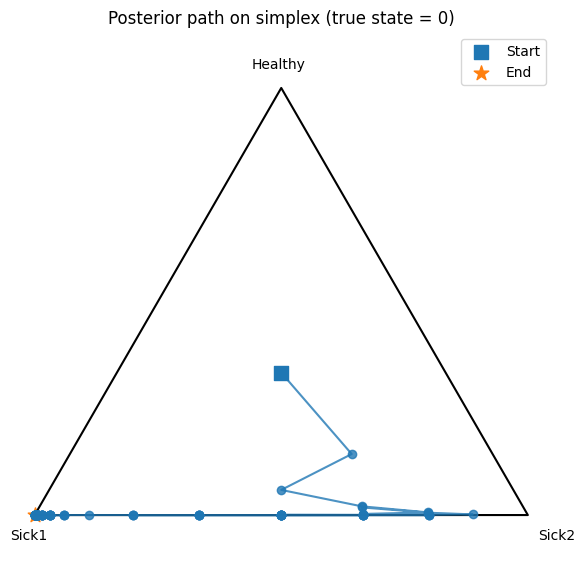

In [13]:
plot_simplex_path(result["posterior_history"], true_state=0)

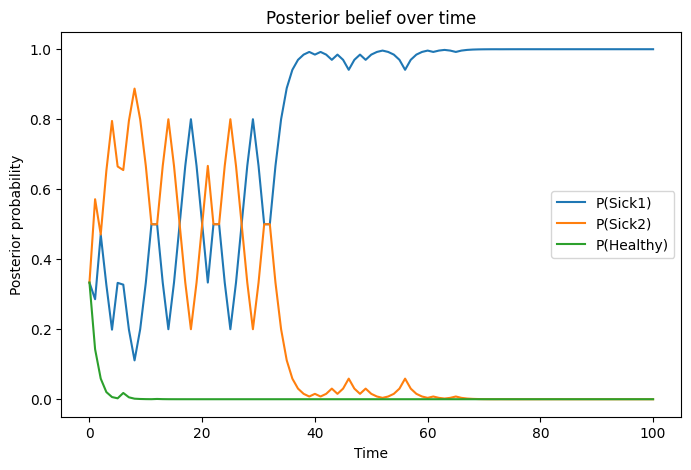

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(result["posterior_history"][:, 0], label="P(Sick1)")
plt.plot(result["posterior_history"][:, 1], label="P(Sick2)")
plt.plot(result["posterior_history"][:, 2], label="P(Healthy)")
plt.xlabel("Time")
plt.ylabel("Posterior probability")
plt.title("Posterior belief over time")
plt.legend()
plt.show()

## Try your own parameters

[[0.55 0.35 0.1 ]
 [0.35 0.55 0.1 ]
 [0.1  0.1  0.8 ]]
Row sums: [1. 1. 1.]


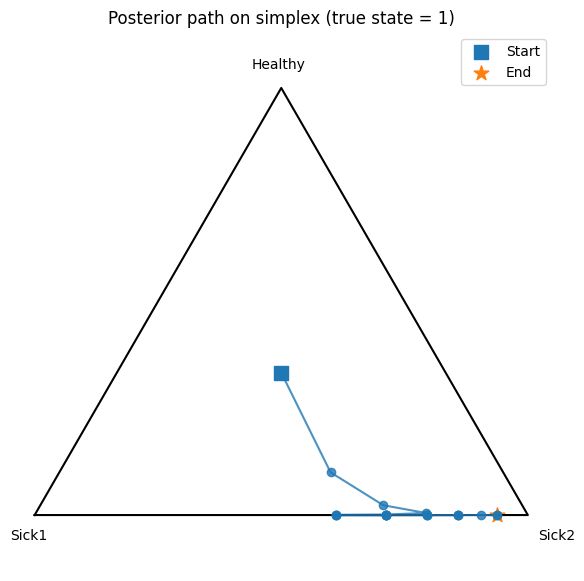

In [15]:
L_custom = make_likelihood(alpha=0.55, beta=0.35, z=0.1)
print(L_custom)
print("Row sums:", L_custom.sum(axis=1))

result_custom = simulate(true_state=1, T=20, L=L_custom, prior=prior, seed=7)
plot_simplex_path(result_custom["posterior_history"], true_state=1)